# Production-Ready QA Agent with Intent Routing, Web Search, and Synthesis

This notebook contains the complete, modular **QA Agent** architecture built with **LangGraph**, **Mistral AI**, and **Tavily Web Search**.

All evaluation-specific boilerplate has been removed so you can easily understand, modify, and extend the agent's capabilities.

### Agent Architecture:
1. **Configuration & Constants**: Environment variables, API keys, LangSmith tracing, and date anchoring.
2. **State Schema (`QAState`)**: Graph memory passed between nodes.
3. **Structured Intent Classifier**: Determines if a query requires live web search and calculates optimal `max_results`.
4. **Query Optimizer & Noise Cleaner**: Regex cleanup for cleaner search tokens and stripped boilerplate.
5. **Contextual Compressor**: LLM-powered factual extraction from search results.
6. **Tavily Search Client**: Wrapper for web search execution.
7. **LangGraph State Machine (`QAAgent`)**: Conditional routing between direct answers and search synthesis.

## 1. Imports and Dependencies

Import standard libraries, Pydantic for validation, LangChain/Mistral for LLM execution, LangGraph for workflow state orchestration, and Tavily for search.

In [10]:
# Core standard libraries
import os
import json
import re
from enum import Enum
from typing import TypedDict, Literal, Any, Optional, List, Dict, Tuple
from datetime import datetime

# Environment variable management
from dotenv import load_dotenv

# Data validation and schema definition
from pydantic import BaseModel, Field, ValidationError

# LangChain and Mistral LLM / Embeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings

# LangGraph for workflow state machine
from langgraph.graph import StateGraph, START, END

# Web search tool & tracing
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper
from langsmith import traceable

# Code Ingestion & Vector Store
from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language
from langchain_chroma import Chroma

import tempfile

## 2. Configuration and Environment Setup

The `Config` class loads API keys from your `.env` file and initializes LangSmith tracing settings.

In [11]:
class Config:
    """Central configuration management for the QA Agent."""
    
    def __init__(self):
        """Initialize configuration from environment variables."""
        load_dotenv(override=True)
        
        self.MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")
        self.TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
        
        self.LANGSMITH_PROJECT = os.getenv(
            "LANGSMITH_PROJECT",
            "qa-agent-phase-2"
        )
        
        # Configure LangSmith tracing
        os.environ["LANGCHAIN_TRACING_V2"] = os.getenv(
            "LANGSMITH_TRACING", 
            "true"
        )
        os.environ["LANGSMITH_TRACING"] = os.getenv(
            "LANGSMITH_TRACING", 
            "true"
        )
        os.environ["LANGSMITH_API_KEY"] = os.getenv(
            "LANGSMITH_API_KEY", 
            ""
        )
        os.environ["LANGSMITH_ENDPOINT"] = os.getenv(
            "LANGSMITH_ENDPOINT",
            "https://api.smith.langchain.com"
        )
        os.environ["LANGCHAIN_PROJECT"] = self.LANGSMITH_PROJECT
        os.environ["LANGSMITH_PROJECT"] = self.LANGSMITH_PROJECT
        
        # Validate required API keys
        self._validate_environment()
    
    def _validate_environment(self):
        """Validate that all required environment variables are present."""
        if not self.MISTRAL_API_KEY:
            raise ValueError("MISTRAL_API_KEY is missing.")
        
        if not self.TAVILY_API_KEY:
            raise ValueError("TAVILY_API_KEY is missing.")

## 3. System Constants

Limits for search result counts and date anchor for relative temporal questions (e.g., *latest*, *current*, *today*).

In [12]:
# Default search parameters and date anchoring
DEFAULT_MAX_RESULTS = 3
MIN_MAX_RESULTS = 2
MAX_MAX_RESULTS = 10
CURRENT_DATE = datetime.now().strftime("%Y-%m-%d")

## 4. State Definition (`QAState`)

`QAState` represents the memory dictionary passed across the LangGraph state machine.

In [13]:
class RouteDecision(str, Enum):
    DIRECT = "direct"
    WEB_SEARCH = "web_search"
    RAG = "rag"

class QAState(TypedDict):
    """State schema for the 3-Way QA agent graph with Phase 4 robustness."""
    query: str
    route: RouteDecision
    needs_web_search: bool
    max_results: int
    search_results: List[Dict[str, Any]]
    retrieved_chunks: List[Dict[str, Any]]  # [{content, source_file, score}]
    answer: str
    
    # === Phase 4: Robustness & Observability ===
    error_log: List[str]       # Running log of caught errors or fallback reasons
    retry_count: int           # Total number of retries performed during this run
    fallback_used: bool        # True if a fallback node was executed instead of primary path


## 5. Pydantic Models for Structured Output

Defines the structured output schema for the intent router.

In [14]:
class IntentClassification(BaseModel):
    """Structured output for 3-way intent classification."""
    
    route: RouteDecision = Field(
        description=(
            "Routing decision for the query: "
            "'direct' for stable/general programming concepts, math, logic, and definitions; "
            "'web_search' for real-time data, current software versions, prices, live news, or external web facts; "
            "'rag' for specific codebase implementation questions, internal repo functions, classes, architecture, or codebase files."
        )
    )
    
    max_results: int = Field(
        default=3,
        ge=2,
        le=10,
        description=(
            "Number of search results or code snippets needed. "
            "Default 3. Use 4-6 for complex multi-file codebase lookups or broad web queries."
        )
    )
    
    reasoning: str = Field(
        description="Detailed explanation justifying the chosen route and result count."
    )


# Section 5.1: Code Ingestion & Vector Store Client

In [15]:
import os
import mimetypes
from pathlib import Path
from typing import List, Dict, Any, Optional, Callable

from langchain_core.documents import Document
from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language
from langchain_chroma import Chroma
from langchain_mistralai import MistralAIEmbeddings


# ============================================================
# Dynamic File Filter & Exclusion Rules
# ============================================================

# Directories to always ignore (dependencies, caches, build artifacts, vcs)
IGNORED_DIR_NAMES = {
    # Version control
    ".git", ".svn", ".hg",
    # Dependencies & environments
    "node_modules", "venv", ".venv", "env", ".env", "vendor", "packages", "bower_components",
    # Caches & temporary files
    "__pycache__", ".cache", ".pytest_cache", ".mypy_cache", ".ruff_cache", ".tox", ".idea", ".vscode",
    # Build outputs & binaries
    "dist", "build", "target", "out", "bin", "obj", "coverage", ".next", ".nuxt", ".turbo",
    "bundle", "wheels", ".gradle"
}

# Specific filenames to ignore (lockfiles, system noise)
IGNORED_FILE_NAMES = {
    # Lockfiles (huge token footprint, little semantic QA value)
    "package-lock.json", "yarn.lock", "pnpm-lock.yaml", "poetry.lock",
    "cargo.lock", "pipfile.lock", "composer.lock", "flake.lock", "gemfile.lock",
    # System artifacts
    ".ds_store", "thumbs.db", "desktop.ini"
}

# Extensions to strictly reject (binaries, media, datasets, archives)
IGNORED_EXTENSIONS = {
    # Media & Images
    ".png", ".jpg", ".jpeg", ".gif", ".ico", ".webp", ".svg", ".bmp", ".tiff",
    ".mp4", ".mov", ".avi", ".mkv", ".mp3", ".wav",
    # Compiled / Executables / Libraries
    ".pyc", ".pyo", ".pyd", ".class", ".jar", ".war", ".exe", ".dll", ".so", ".dylib", ".o", ".a", ".wasm",
    # Fonts
    ".woff", ".woff2", ".ttf", ".eot", ".otf",
    # Archives & Compressed files
    ".zip", ".tar", ".gz", ".tgz", ".7z", ".rar", ".bz2", ".xz",
    # Datasets & Databases
    ".sqlite", ".sqlite3", ".db", ".parquet", ".arrow", ".avro", ".bin", ".dat", ".pkl", ".pickle",
    # Large Document / Design Formats
    ".pdf", ".docx", ".xlsx", ".pptx", ".psd", ".ai", ".fig"
}

# Mapping file extensions to LangChain Language enum for AST/syntax-aware chunking
EXTENSION_TO_LANGUAGE = {
    ".py": Language.PYTHON,
    ".js": Language.JS,
    ".mjs": Language.JS,
    ".cjs": Language.JS,
    ".jsx": Language.JS,
    ".ts": Language.TS,
    ".tsx": Language.TS,
    ".html": Language.HTML,
    ".htm": Language.HTML,
    ".md": Language.MARKDOWN,
    ".markdown": Language.MARKDOWN,
    ".go": Language.GO,
    ".rs": Language.RUST,
    ".java": Language.JAVA,
    ".cpp": Language.CPP,
    ".cc": Language.CPP,
    ".cxx": Language.CPP,
    ".c": Language.C,
    ".h": Language.C,
    ".hpp": Language.CPP,
    ".cs": Language.CSHARP,
    ".php": Language.PHP,
    ".rb": Language.RUBY,
    ".scala": Language.SCALA,
    ".swift": Language.SWIFT,
    ".sol": Language.SOL,
}


def is_binary_or_oversized(
    filepath: str, 
    max_file_size_kb: int = 500,
    sample_bytes: int = 4096
) -> bool:
    """
    Dynamically inspects a file to determine if it is binary, empty, or oversized.
    
    Args:
        filepath: Full path to the file on disk
        max_file_size_kb: Maximum allowed file size in Kilobytes
        sample_bytes: Number of bytes to probe for null-byte detection
        
    Returns:
        True if the file should be EXCLUDED (binary/empty/oversized), False if text-based.
    """
    try:
        if not os.path.isfile(filepath):
            return True
            
        size_bytes = os.path.getsize(filepath)
        
        # Exclude 0-byte files or files exceeding max size limit
        if size_bytes == 0 or size_bytes > (max_file_size_kb * 1024):
            return True
        
        # Probe the first N bytes for null bytes (canonical binary check)
        with open(filepath, "rb") as f:
            chunk = f.read(sample_bytes)
            if b"\x00" in chunk:
                return True
                
        # Attempt UTF-8 decoding to confirm it is readable text
        try:
            chunk.decode("utf-8")
            return False
        except UnicodeDecodeError:
            # If UTF-8 fails, check if latin-1 decoded content is mostly printable
            try:
                decoded = chunk.decode("latin-1")
                printable_ratio = sum(c.isprintable() or c.isspace() for c in decoded) / len(decoded)
                return printable_ratio < 0.85
            except Exception:
                return True
                
    except Exception:
        return True


def create_repo_file_filter(
    repo_root_dir: str, 
    max_file_size_kb: int = 500
) -> Callable[[str], bool]:
    """
    Creates a filtering predicate for GitLoader that applies directory exclusions,
    filename exclusions, and dynamic text/binary inspection.
    """
    def file_filter(relative_path: str) -> bool:
        path_parts = Path(relative_path).parts
        file_name = path_parts[-1].lower() if path_parts else ""
        _, ext = os.path.splitext(file_name)
        
        # 1. Exclude ignored directory segments (e.g., node_modules, .git, venv)
        for part in path_parts[:-1]:
            if part.lower() in IGNORED_DIR_NAMES or part.startswith("."):
                if part.lower() not in {".github", ".devcontainer"}:  # Allow common CI configs
                    return False
        
        # 2. Exclude known lockfiles and junk filenames
        if file_name in IGNORED_FILE_NAMES:
            return False
            
        # 3. Exclude known binary and media extensions
        if ext in IGNORED_EXTENSIONS:
            return False
            
        # 4. Dynamic on-disk check (size + binary byte probing)
        full_path = os.path.join(repo_root_dir, relative_path)
        if os.path.exists(full_path):
            if is_binary_or_oversized(full_path, max_file_size_kb=max_file_size_kb):
                return False
                
        return True

    return file_filter


# ============================================================
# Dynamic Code Ingestion Pipeline
# ============================================================

class CodeIngestionPipeline:
    """Ingests, dynamically filters, syntax-splits, and indexes multi-language repositories."""
    
    def __init__(
        self, 
        persist_directory: str = "./chroma_code_db",
        default_chunk_size: int = 900,
        default_chunk_overlap: int = 120,
        max_file_size_kb: int = 500
    ):
        self.persist_directory = persist_directory
        self.default_chunk_size = default_chunk_size
        self.default_chunk_overlap = default_chunk_overlap
        self.max_file_size_kb = max_file_size_kb
        self.embeddings = MistralAIEmbeddings(model="mistral-embed")
        
        # Fallback generic text splitter
        self.default_splitter = RecursiveCharacterTextSplitter(
            chunk_size=default_chunk_size,
            chunk_overlap=default_chunk_overlap,
        )

    def _split_document_by_language(self, doc: Document) -> List[Document]:
        """Splits a single document using its language-specific AST splitter if available."""
        source_path = doc.metadata.get("source", "")
        _, ext = os.path.splitext(source_path.lower())
        
        # Select appropriate language-aware splitter or fallback to generic
        if ext in EXTENSION_TO_LANGUAGE:
            language = EXTENSION_TO_LANGUAGE[ext]
            splitter = RecursiveCharacterTextSplitter.from_language(
                language=language,
                chunk_size=self.default_chunk_size,
                chunk_overlap=self.default_chunk_overlap,
            )
        else:
            splitter = self.default_splitter
            
        return splitter.split_documents([doc])

    def ingest_from_git(
    self,
    clone_url: str,
    branch: Optional[str] = None
) -> Chroma:
        """
        Temporarily clones a repository, filters and chunks its files,
        stores embeddings in ChromaDB, then automatically deletes
        the temporary repository.
        """
        print(f"📥 Loading repository: {clone_url} ...")

        with tempfile.TemporaryDirectory(ignore_cleanup_errors=True) as temp_dir:

            # Create dynamic filter for the temporary repository
            dynamic_filter = create_repo_file_filter(
                repo_root_dir=temp_dir,
                max_file_size_kb=self.max_file_size_kb
            )

            loader = GitLoader(
                clone_url=clone_url,
                repo_path=temp_dir,
                branch=branch,
                file_filter=dynamic_filter,
            )

            raw_docs = loader.load()

            print(f"📄 Ingested {len(raw_docs)} valid text/code files.")

            if not raw_docs:
                raise ValueError(
                    "No text-based code or config files matched the filter criteria."
                )

            # Split documents using language-aware splitters
            all_chunks: List[Document] = []

            for doc in raw_docs:
                chunks = self._split_document_by_language(doc)
                all_chunks.extend(chunks)

            print(
                f"🧩 Generated {len(all_chunks)} syntax-aware "
                f"chunks across all languages."
            )

            print(
                f"💾 Persisting embeddings into ChromaDB "
                f"at '{self.persist_directory}'..."
            )

            vector_store = Chroma.from_documents(
                documents=all_chunks,
                embedding=self.embeddings,
                persist_directory=self.persist_directory,
            )

            print("✅ Ingestion successfully completed!")

        # Temporary repository is automatically deleted here
        print("🗑️ Temporary repository deleted.")

        return vector_store

class VectorStoreClient:
    """Wraps Chroma vector store for similarity retrieval."""
    
    def __init__(self, persist_directory: str = "./chroma_code_db"):
        self.persist_directory = persist_directory
        self.embeddings = MistralAIEmbeddings(model="mistral-embed")
        self.vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=self.embeddings,
        )
    def retrieve(self, query: str, k: int = 4) -> List[Dict[str, Any]]:
        """Retrieve top-k relevant code snippets with relevance score."""
        try:
            docs_and_scores = self.vector_store.similarity_search_with_relevance_scores(query, k=k)
            results = []
            for doc, score in docs_and_scores:
                results.append({
                    "content": doc.page_content,
                    "source_file": doc.metadata.get("source", "unknown"),
                    "score": round(score, 4),
                })
            return results
        except Exception as e:
            print(f"⚠️ Vector retrieval error: {e}")
            return []

### Section 5.2: Exponential Backoff Retry Policy

In [16]:
# ============================================================
# Phase 4 Resilience: Exponential Backoff Retry Policy
# ============================================================

import random
import time

class RetryPolicy:
    """Configurable exponential backoff retry handler for external API calls."""
    
    def __init__(
        self,
        max_retries: int = 2,
        initial_delay: float = 1.0,
        backoff_factor: float = 2.0,
        max_delay: float = 8.0,
    ):
        self.max_retries = max_retries
        self.initial_delay = initial_delay
        self.backoff_factor = backoff_factor
        self.max_delay = max_delay

    def execute(self, action_name: str, fn, *args, **kwargs) -> Any:
        """
        Executes fn(*args, **kwargs). If a transient exception occurs,
        retries up to max_retries with jittered exponential backoff.
        """
        last_error = None
        for attempt in range(self.max_retries + 1):
            try:
                return fn(*args, **kwargs)
            except Exception as e:
                last_error = e
                # Check for fatal client errors where retrying is futile (e.g., bad API keys)
                err_str = str(e).lower()
                if "unauthorized" in err_str or "invalid api key" in err_str or "forbidden" in err_str:
                    print(f"❌ [Fatal Error] Non-retryable error in {action_name}: {e}")
                    raise e

                if attempt < self.max_retries:
                    # Calculate delay with jitter
                    base_delay = min(self.max_delay, self.initial_delay * (self.backoff_factor ** attempt))
                    jitter = random.uniform(0.1, 0.5)
                    delay = base_delay + jitter
                    print(f"⚠️ [{action_name}] Attempt {attempt + 1} failed: {e}. Retrying in {delay:.2f}s...")
                    time.sleep(delay)
                else:
                    print(f"❌ [{action_name}] All {self.max_retries + 1} attempts exhausted. Last error: {e}")
                    raise last_error


## 6. LLM Client Wrapper

Wraps `ChatMistralAI` with configuration, retries, and LangSmith tracing.

In [17]:
class LLMClient:
    """Wrapper for LLM interactions with structured output support."""
    
    def __init__(
        self,
        model: str = "mistral-small-latest",
        temperature: float = 0.1,
        max_retries: int = 3,
        timeout: int = 60,
        api_key: Optional[str] = None
    ):
        """
        Initialize LLM client.
        
        Args:
            model: Model name to use
            temperature: Sampling temperature
            max_retries: Maximum retry attempts
            timeout: Request timeout in seconds
            api_key: Mistral API key (defaults to environment variable)
        """
        self.model = model
        self.temperature = temperature
        self.max_retries = max_retries
        
        # Get API key from parameter or environment
        self.api_key = api_key or os.getenv("MISTRAL_API_KEY")
        
        if not self.api_key:
            raise ValueError("MISTRAL_API_KEY is not configured.")
        
        self.llm = ChatMistralAI(
            model=model,
            temperature=temperature,
            max_retries=max_retries,
            timeout=timeout,
            api_key=self.api_key,
        )
    
    @traceable(name="LLMClient.invoke")
    def invoke(self, messages: List[Any]) -> Any:
        """Invoke LLM with provided messages."""
        return self.llm.invoke(messages)
    
    @traceable(name="LLMClient.with_structured_output")
    def with_structured_output(self, schema: type[BaseModel]) -> Any:
        """Get LLM with structured output support."""
        return self.llm.with_structured_output(schema)

## 7. Structured Output Handler

`StructuredOutputNode` guarantees valid JSON output by catching Pydantic validation errors and feeding back the error message to the LLM for correction.

In [18]:
class StructuredOutputNode:
    """Handler for structured LLM outputs with self-repair and graceful circuit breaking."""
    
    def __init__(
        self,
        llm_client: LLMClient,
        schema: type[BaseModel],
        system_prompt: str,
        max_repair_attempts: int = 1,
    ):
        self.llm_client = llm_client
        self.schema = schema
        self.system_prompt = system_prompt
        self.max_repair_attempts = max_repair_attempts
    
    @traceable(name="StructuredOutputNode.invoke")
    def invoke(self, user_input: str) -> Tuple[BaseModel, List[str]]:
        """
        Invoke LLM with structured output and retry on validation failure.
        
        Returns:
            Tuple of (Validated structured object, error_logs)
            Never throws RuntimeError; gracefully falls back on failure.
        """
        errors: List[str] = []
        structured_llm = self.llm_client.with_structured_output(self.schema)
        
        messages = [
            SystemMessage(content=self.system_prompt),
            HumanMessage(content=user_input),
        ]
        
        for attempt in range(self.max_repair_attempts + 1):
            try:
                response = structured_llm.invoke(messages)
                
                if isinstance(response, self.schema):
                    return response, errors
                
                validated = self.schema.model_validate(response)
                return validated, errors
                
            except (ValidationError, ValueError, TypeError) as error:
                err_msg = f"Validation attempt {attempt + 1} failed: {error}"
                errors.append(err_msg)
                
                if attempt >= self.max_repair_attempts:
                    break
                
                # Feedback loop to repair JSON
                repair_message = f"""
Your previous structured response failed validation.
Error: {error}
Please correct the output and return ONLY valid JSON matching the schema.
"""
                messages.append(HumanMessage(content=repair_message))
        
        # === Circuit Breaker Fallback ===
        warning = f"Circuit breaker tripped: Structured output failed {self.max_repair_attempts + 1} attempts. Falling back to default DIRECT."
        errors.append(warning)
        print(f"🛡️ {warning}")
        
        # Safe default instance
        fallback_obj = IntentClassification(
            route=RouteDecision.DIRECT,
            max_results=3,
            reasoning="Fallback default triggered: LLM structured output repair attempts exhausted."
        )
        return fallback_obj, errors


## 8. Utility Functions

Helper functions for result limit bounds, LLM context formatting, and citation URL extraction.

In [19]:
def sanitize_max_results(
    value: Optional[int],
    default: int = DEFAULT_MAX_RESULTS,
) -> int:
    """
    Sanitize max_results value.
    
    Rules:
    - None -> default
    - Invalid value -> default
    - Below minimum -> minimum
    - Above maximum -> maximum
    
    Args:
        value: Input value to sanitize
        default: Default value to use when input is invalid
        
    Returns:
        Sanitized integer value
    """
    if value is None:
        value = default
    
    try:
        value = int(value)
    except (TypeError, ValueError):
        value = default
    
    return max(MIN_MAX_RESULTS, min(value, MAX_MAX_RESULTS))


def format_search_results_for_llm(results: List[Dict]) -> str:
    """
    Format search results for LLM consumption.
    
    Args:
        results: List of search result dictionaries
        
    Returns:
        Formatted string with search results
    """
    if not results:
        return "No web search results were found."
    
    blocks = []
    
    for result in results:
        block = f"""
SOURCE {result['id']}

Title:
{result['title']}

URL:
{result['url']}

Relevance score:
{result['score']}

Content:
{result['content']}
"""
        blocks.append(block.strip())
    
    return "\n\n".join(blocks)


def extract_sources_from_answer(answer: str) -> List[str]:
    """
    Extract source URLs from answer text.
    
    Args:
        answer: Answer text with citations
        
    Returns:
        List of source URLs found in the answer
    """
    # Pattern to match URLs
    url_pattern = r'https?://[^\s\[\]]+'
    sources = re.findall(url_pattern, answer)
    
    return list(set(sources))  # Remove duplicates


def format_code_chunks_for_llm(chunks: List[Dict[str, Any]]) -> str:
    """Format retrieved code snippets with file paths and metadata for LLM prompt."""
    if not chunks:
        return "No relevant code snippets were found in the codebase."
    
    blocks = []
    for idx, chunk in enumerate(chunks, start=1):
        source = chunk.get("source_file", "unknown")
        score = chunk.get("score", 0.0)
        code = chunk.get("content", "").strip()
        
        block = f"""### CODE SNIPPET {idx}
File: `{source}` (Relevance Score: {score})
```python
{code}
```"""
        blocks.append(block)
    
    return "\n\n".join(blocks)


## 9. Search Optimization, Boilerplate Cleaning & Compression

Cleans web artifacts, optimizes queries, and uses extractive contextual compression to keep only high-precision facts.

In [20]:
def clean_boilerplate(text: str) -> str:
    """
    Remove webpage artifacts, boilerplate, navigation, and junk tokens from raw text.
    
    Args:
        text: Raw input text from webpage
        
    Returns:
        Cleaned text with boilerplate removed
    """
    if not text:
        return ""
    
    # Remove repetitive image placeholders and UI junk
    text = re.sub(r'(?:slider-image|thumbnail-image|Icon image|Mini Product ImageView|Screenshot image)\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Flag\s+[A-Z\-]+\s*|null\s+[A-Z\-]+\s+Flag', '', text)
    text = re.sub(r'DUR\s+Flag.*?null\s*', '', text)
    
    # Remove App Store / Play Store boilerplate
    text = re.sub(r'#(?:Play Pass|Play Points|Gift cards|Redeem|Refund policy|Parent Guide|Family sharing|Content rating|About Google Play).*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(?:Play Pass|Play Points|Gift cards|Refund policy|Parent Guide|Family sharing)\b', '', text, flags=re.IGNORECASE)
    
    # Remove login and registration forms
    text = re.sub(r'User Name:\s*\\*\s*\\*.*?(?=New Registration|Registration Closed|$)', '', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'If you are already registered, please enter user name and password to login\.?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Forgot Password\?|New Registration|Registration Closed', '', text, flags=re.IGNORECASE)
    
    # Remove social media / author subscription noise
    text = re.sub(r'You\'re currently following this author!.*?(?:email\.)', '', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'Unsubscribe via the link in your email\.?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'We earn a commission if you make a purchase.*?\.', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Add as a preferred source on Google', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Skip to (?:main )?content|Back to Top|Quick Links|Terms and Conditions|Site Map', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Style\s*"Style\s*\(form of address\)"\s*\|\s*The Honourable\s*Mr\.\s*Prime Minister\s*\(informal\)\s*His Excellency\s*\(diplomatic\)', '', text, flags=re.IGNORECASE)
    text = re.sub(r'State Emblem of Pakistan\s*\|\s*\|\s*Prime ministerial standard', '', text, flags=re.IGNORECASE)
    
    # Clean broken markdown table delimiters
    text = re.sub(r'(\|\s*){3,}', '| ', text)
    text = re.sub(r'---(\s*---)+', '---', text)
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def optimize_search_query(query: str) -> Dict[str, Any]:
    """
    Determine search parameters and optimized query string.
    
    Args:
        query: Raw input search query
        
    Returns:
        Dictionary containing optimized_query, topic, and search_depth
    """
    q_lower = query.lower()
    
    # Determine topic
    finance_keywords = [
        "stock", "price", "mortgage", "remittance", "exchange rate", 
        "usd to pkr", "pkr", "rate", "cost", "pricing", "budget", "tax", "gdp"
    ]
    news_keywords = [
        "news", "earthquake", "update", "recent", "breaking", 
        "announced", "grok", "llama", "drop a new model", "releasing"
    ]
    
    topic = "general"
    if any(k in q_lower for k in finance_keywords):
        topic = "finance"
    elif any(k in q_lower for k in news_keywords):
        topic = "news"
        
    # Clean slang and common colloquialisms / Roman Urdu phrasing
    clean_q = query
    clean_q = re.sub(r'\bfr\s+fr\b', '', clean_q, flags=re.IGNORECASE)
    clean_q = re.sub(r'\bkaise\s+karen\b', 'process guide', clean_q, flags=re.IGNORECASE)
    clean_q = re.sub(r'\bkab\s+announce\s+hoga\??', 'announcement schedule date', clean_q, flags=re.IGNORECASE)
    clean_q = re.sub(r'\bka\s+recent\s+update\s+kya\s+hai\??', 'latest updates features', clean_q, flags=re.IGNORECASE)
    clean_q = re.sub(r'\bmein\s+kya\s+hai\??', 'policy details', clean_q, flags=re.IGNORECASE)
    clean_q = re.sub(r'\bse\b', '', clean_q, flags=re.IGNORECASE)
    clean_q = re.sub(r'\s+', ' ', clean_q).strip()
    
    return {
        "optimized_query": clean_q if len(clean_q) > 3 else query,
        "topic": topic,
        "search_depth": "advanced"
    }


def compress_search_snippets(
    query: str, 
    snippets: List[Dict[str, Any]], 
    llm_client: Optional[LLMClient] = None
) -> List[Dict[str, Any]]:
    """
    Compress and extract only query-relevant facts from search results using LLM.
    
    Args:
        query: User's question or search query
        snippets: List of raw search result dictionaries
        llm_client: LLMClient instance for contextual extraction
        
    Returns:
        List of compressed search results containing only relevant statements
    """
    if not snippets:
        return []
    
    if llm_client is None:
        # Fallback to rule-based cleaning
        for s in snippets:
            s["content"] = clean_boilerplate(s.get("content", ""))
        return [s for s in snippets if s.get("content")]
    
    formatted_docs = []
    for i, s in enumerate(snippets, start=1):
        content = clean_boilerplate(s.get("content", ""))
        title = s.get("title", "")
        formatted_docs.append(f"<SOURCE {i}>\nTitle: {title}\nContent: {content}\n</SOURCE {i}>\n")
    
    prompt = f"""You are an extractive contextual compressor for a search retrieval system.
Your job is to extract ONLY the factual sentences, numbers, dates, and specifications from the search results that are DIRECTLY AND STRICTLY RELEVANT to answering the user query.

<USER_QUERY>
{query}
</USER_QUERY>

<SEARCH_RESULTS>
{''.join(formatted_docs)}
</SEARCH_RESULTS>

CRITICAL INSTRUCTIONS:
1. For each source, extract ONLY the exact sentences/facts that directly answer what the user asked.
2. If the user asks for 'current', 'latest', 'today', 'price', or a specific entity/value, focus strictly on the current state, incumbent, or latest figures. Do NOT include past predecessors, historical timelines, founding history, employee counts, or general off-topic background.
3. Completely OMIT all irrelevant sentences, navigation noise, unrelated product reviews, off-topic trivia, company boilerplate, and marketing text.
4. Keep the extraction compact, dense, and high-precision (1-3 key sentences per source).
5. If a source contains no directly relevant information, output "NONE" for that source.
6. Output your response in the exact format:
SOURCE 1: <extracted relevant text or NONE>
SOURCE 2: <extracted relevant text or NONE>
...
"""
    
    try:
        messages = [
            SystemMessage(content="You are a precise fact extractor. Extract only relevant statements. Omit all noise."),
            HumanMessage(content=prompt)
        ]
        response = llm_client.invoke(messages)
        content_out = response.content if hasattr(response, "content") else str(response)
        
        # Parse SOURCE X: ...
        pattern = r'SOURCE\s+(\d+):\s*(.*?)(?=(?:SOURCE\s+\d+:|$))'
        matches = re.findall(pattern, content_out, flags=re.DOTALL)
        
        compressed_results = []
        parsed_dict = {int(idx): text.strip() for idx, text in matches}
        
        for i, s in enumerate(snippets, start=1):
            extracted = parsed_dict.get(i, "").strip()
            if extracted and extracted != "NONE" and len(extracted) > 10:
                s_copy = dict(s)
                s_copy["content"] = clean_boilerplate(extracted)
                compressed_results.append(s_copy)
            elif clean_boilerplate(s.get("content", "")):
                # Fallback if parsing missed the source but original had content
                if i not in parsed_dict:
                    s_copy = dict(s)
                    s_copy["content"] = clean_boilerplate(s.get("content", ""))
                    compressed_results.append(s_copy)
        
        # Renumber IDs
        for idx, res in enumerate(compressed_results, start=1):
            res["id"] = idx
            
        return compressed_results if compressed_results else snippets
        
    except Exception as error:
        # Fallback to rule-based cleaned snippets on error
        cleaned_list = []
        for idx, s in enumerate(snippets, start=1):
            cleaned_content = clean_boilerplate(s.get("content", ""))
            if cleaned_content:
                s_copy = dict(s)
                s_copy["id"] = idx
                s_copy["content"] = cleaned_content
                cleaned_list.append(s_copy)
        return cleaned_list if cleaned_list else snippets

## 10. Tavily Search Client

`TavilySearchClient` performs search queries and integrates query optimization and LLM contextual compression.

In [21]:
class TavilySearchClient:
    """Client for performing web searches using Tavily with optimization and compression."""
    
    def __init__(
        self,
        api_key: Optional[str] = None,
        timeout: int = 15,
        default_max_results: int = DEFAULT_MAX_RESULTS,
        llm_client: Optional[LLMClient] = None,
    ):
        """
        Initialize Tavily search client.
        
        Args:
            api_key: Tavily API key (defaults to environment variable)
            timeout: Request timeout in seconds
            default_max_results: Default number of search results
            llm_client: Optional LLMClient for contextual compression
        """
        self.api_key = api_key or os.getenv("TAVILY_API_KEY")
        
        if not self.api_key:
            raise ValueError("TAVILY_API_KEY is not configured.")
        
        self.timeout = timeout
        self.default_max_results = sanitize_max_results(default_max_results)
        self.llm_client = llm_client
        self.api_wrapper = TavilySearchAPIWrapper(tavily_api_key=self.api_key)
    
    @traceable(name="TavilySearchClient.search")
    def search(
        self,
        query: str,
        max_results: Optional[int] = None,
        enable_compression: bool = True,
    ) -> List[Dict[str, Any]]:
        """
        Perform optimized web search using Tavily and contextual compression.
        
        Args:
            query: Search query string
            max_results: Maximum number of results to return
            enable_compression: Whether to apply LLM contextual compression
            
        Returns:
            List of formatted search results
            
        Raises:
            ValueError: If query is empty
            RuntimeError: If search fails
        """
        # Validate query
        if not query or not query.strip():
            raise ValueError("Search query cannot be empty.")
        
        # Sanitize max_results
        max_results = sanitize_max_results(
            max_results,
            default=self.default_max_results,
        )
        
        # Optimize query and determine search topic/depth
        opt = optimize_search_query(query.strip())
        
        # Execute search via Tavily API wrapper
        try:
            raw_response = self.api_wrapper.raw_results(
                query=opt["optimized_query"],
                max_results=max_results,
                search_depth=opt["search_depth"],
                include_answer=True,
                include_raw_content=False,
                include_images=False,
            )
        except Exception as error:
            raise RuntimeError(f"Tavily search failed: {error}") from error
        
        # Normalize results
        formatted = self._format_results(raw_response.get("results", []))
        
        # Apply contextual compression and filtering
        if enable_compression and self.llm_client:
            formatted = compress_search_snippets(
                query=query,
                snippets=formatted,
                llm_client=self.llm_client,
            )
        else:
            for s in formatted:
                s["content"] = clean_boilerplate(s.get("content", ""))
                
        return formatted
    
    def _format_results(self, results: Any) -> List[Dict[str, Any]]:
        """
        Normalize Tavily search results.
        
        Args:
            results: Raw Tavily search results
            
        Returns:
            Formatted list of search results
        """
        if not isinstance(results, list):
            return []
        
        formatted = []
        
        for index, result in enumerate(results, start=1):
            if not isinstance(result, dict):
                continue
            
            raw_content = result.get("content", "")
            formatted.append({
                "id": index,
                "title": result.get("title", ""),
                "url": result.get("url", ""),
                "content": clean_boilerplate(raw_content),
                "score": result.get("score"),
            })
        
        return formatted

## 11. QA Agent Class (`QAAgent`)

`QAAgent` manages the full LangGraph workflow:
- Classifies intent (`_classify_intent`)
- Conditionally branches to direct answer (`_answer_direct`) or web search + synthesis (`_web_search` -> `_synthesize`)
- Provides high-level `.invoke(query)` and `.get_answer(query)` methods.

In [22]:
class QAAgent:
    """Production QA Agent with 3-Way Intent Routing, Resilience Policies & Graceful Fallbacks."""
    
    def __init__(
        self,
        model: str = "mistral-small-latest",
        temperature: float = 0.1,
        vector_db_path: str = "./chroma_code_db",
        config: Optional[Config] = None,
    ):
        self.config = config or Config()
        
        # Initialize LLM client
        self.llm_client = LLMClient(
            model=model,
            temperature=temperature,
        )
        
        # Initialize Retry Policy
        self.retry_policy = RetryPolicy(max_retries=2, initial_delay=1.0)
        
        # Initialize Intent Router
        self.intent_router = self._create_intent_router()
        
        # Initialize Web Search Client
        self.tavily_client = TavilySearchClient(
            api_key=self.config.TAVILY_API_KEY,
            llm_client=self.llm_client,
        )
        
        # Initialize Vector Store Client
        self.vector_store_client = VectorStoreClient(persist_directory=vector_db_path)
        
        # Build LangGraph 3-Way State Machine with Fallbacks
        self.graph = self._build_graph()
    
    def _create_intent_router(self) -> StructuredOutputNode:
        """Create 3-way intent router with structured output."""
        system_prompt = f"""
You are the intent-classification component of an AI technical engineering assistant.

Classify the user query into EXACTLY ONE of three routes:
1. 'rag': Queries about codebase functions, classes, files, architecture, or repo implementation.
2. 'web_search': Queries requiring current live facts, external package docs, or changing data (Current date: {CURRENT_DATE}).
3. 'direct': Core programming fundamentals, standard library concepts, language syntax, algorithms, or math.

For max_results: Default 3, use 4-6 for complex multi-file codebase lookups or broad web queries.
"""
        return StructuredOutputNode(
            llm_client=self.llm_client,
            schema=IntentClassification,
            system_prompt=system_prompt,
        )
    
    # ---------------- Graph Node Handlers ----------------
    def _classify_intent(self, state: QAState) -> Dict:
        """Node: Classify intent safely without throwing."""
        query = state["query"]
        error_log = list(state.get("error_log", []))
        
        # Structured output invocation (safe with circuit breaker)
        result, router_errors = self.intent_router.invoke(query)
        error_log.extend(router_errors)
        
        max_results = sanitize_max_results(result.max_results)
        needs_web = (result.route == RouteDecision.WEB_SEARCH)
        
        return {
            "route": result.route,
            "needs_web_search": needs_web,
            "max_results": max_results,
            "error_log": error_log,
        }
    
    def _route_after_classification(
        self, 
        state: QAState
    ) -> Literal["answer_direct", "web_search", "retrieve_code"]:
        """Conditional routing based on classified route."""
        route = state.get("route")
        if route == RouteDecision.WEB_SEARCH:
            return "web_search"
        elif route == RouteDecision.RAG:
            return "retrieve_code"
        return "answer_direct"
    
    def _answer_direct(self, state: QAState) -> Dict:
        """Node: Direct technical answering without external tools."""
        query = state["query"]
        messages = [
            SystemMessage(content="You are an expert software engineer. Provide a concise, clear, and accurate answer."),
            HumanMessage(content=query),
        ]
        
        response = self.retry_policy.execute(
            "Direct LLM Answer",
            self.llm_client.invoke,
            messages
        )
        return {"answer": response.content}
    
    def _web_search(self, state: QAState) -> Dict:
        """Node: Web search with retry policy and exception insulation."""
        query = state["query"]
        error_log = list(state.get("error_log", []))
        max_results = sanitize_max_results(state.get("max_results", DEFAULT_MAX_RESULTS))
        
        try:
            results = self.retry_policy.execute(
                "Tavily Web Search",
                self.tavily_client.search,
                query=query,
                max_results=max_results,
            )
            return {"search_results": results, "error_log": error_log}
        except Exception as e:
            error_msg = f"Web search failed after retries: {str(e)}"
            error_log.append(error_msg)
            return {
                "search_results": [],
                "error_log": error_log,
                "fallback_used": True,
            }
    
    def _route_after_search(
        self, 
        state: QAState
    ) -> Literal["synthesize_web", "fallback_direct_answer"]:
        """Route to synthesis if search results exist; otherwise trigger fallback."""
        results = state.get("search_results", [])
        if results and len(results) > 0:
            return "synthesize_web"
        return "fallback_direct_answer"
    
    def _synthesize_web(self, state: QAState) -> Dict:
        """Node: Synthesize answer from verified web search results."""
        query = state["query"]
        search_context = format_search_results_for_llm(state.get("search_results", []))
        
        prompt = f"""You are a research-backed QA assistant. Answer the user query using the web sources below.
Cite sources inline as [1], [2], etc., and list them at the bottom under '### Sources:'.

<USER_QUERY>
{query}
</USER_QUERY>

<WEB_SEARCH_CONTEXT>
{search_context}
</WEB_SEARCH_CONTEXT>
"""
        response = self.retry_policy.execute(
            "Synthesize Web",
            self.llm_client.invoke,
            [
                SystemMessage(content=f"Current date: {CURRENT_DATE}. Ground answers strictly in the search results."),
                HumanMessage(content=prompt)
            ]
        )
        return {"answer": response.content}
    
    def _retrieve_code(self, state: QAState) -> Dict:
        """Node: Retrieve code snippets from vector store with exception insulation."""
        query = state["query"]
        error_log = list(state.get("error_log", []))
        k = sanitize_max_results(state.get("max_results", 4))
        
        try:
            chunks = self.retry_policy.execute(
                "Chroma Vector Retrieval",
                self.vector_store_client.retrieve,
                query=query,
                k=k,
            )
            return {"retrieved_chunks": chunks, "error_log": error_log}
        except Exception as e:
            error_msg = f"Vector retrieval failed: {str(e)}"
            error_log.append(error_msg)
            return {
                "retrieved_chunks": [],
                "error_log": error_log,
                "fallback_used": True,
            }
    
    def _route_after_retrieval(
        self, 
        state: QAState
    ) -> Literal["synthesize_code", "fallback_direct_answer"]:
        """Route to code synthesis if chunks retrieved; otherwise trigger fallback."""
        chunks = state.get("retrieved_chunks", [])
        if chunks and len(chunks) > 0:
            return "synthesize_code"
        return "fallback_direct_answer"
    
    def _synthesize_code(self, state: QAState) -> Dict:
        """Node: Synthesize code answer grounded in codebase chunks."""
        query = state["query"]
        code_context = format_code_chunks_for_llm(state.get("retrieved_chunks", []))
        
        prompt = f"""You are a senior codebase assistant. Answer the user's technical question using the retrieved code snippets below.
Explain how the code works, referencing file paths and functions. At the end, list referenced files.

<USER_QUERY>
{query}
</USER_QUERY>

<CODEBASE_SNIPPETS>
{code_context}
</CODEBASE_SNIPPETS>
"""
        response = self.retry_policy.execute(
            "Synthesize Code",
            self.llm_client.invoke,
            [
                SystemMessage(content="You are a precise codebase analyzer. Always cite file paths when answering."),
                HumanMessage(content=prompt)
            ]
        )
        return {"answer": response.content}
    
    def _fallback_direct_answer(self, state: QAState) -> Dict:
        """
        Node: Graceful Fallback Direct Answer.
        Executed when external web search or codebase retrieval fails or returns 0 results.
        """
        query = state["query"]
        route = state.get("route")
        error_log = state.get("error_log", [])
        
        if route == RouteDecision.WEB_SEARCH:
            reason = "Live web search was temporarily unreachable or returned no relevant sources."
        elif route == RouteDecision.RAG:
            reason = "Codebase search yielded no matching files or the vector database was unavailable."
        else:
            reason = "External retrieval was unable to complete."
            
        disclaimer = f"> ⚠️ **Notice**: {reason} Answering based on internal training knowledge.\n\n"
        
        messages = [
            SystemMessage(content="You are an expert technical assistant. Answer the question directly using your internal knowledge."),
            HumanMessage(content=query),
        ]
        
        response = self.retry_policy.execute(
            "Fallback LLM Answer",
            self.llm_client.invoke,
            messages
        )
        
        return {
            "answer": disclaimer + response.content,
            "fallback_used": True,
        }
    
    # ---------------- Graph Assembly ----------------
    def _build_graph(self):
        """Build the resilient 3-way LangGraph state machine with fallback branches."""
        builder = StateGraph(QAState)
        
        # Register nodes
        builder.add_node("classify_intent", self._classify_intent)
        builder.add_node("answer_direct", self._answer_direct)
        builder.add_node("web_search", self._web_search)
        builder.add_node("synthesize_web", self._synthesize_web)
        builder.add_node("retrieve_code", self._retrieve_code)
        builder.add_node("synthesize_code", self._synthesize_code)
        builder.add_node("fallback_direct_answer", self._fallback_direct_answer)
        
        # Entry point
        builder.add_edge(START, "classify_intent")
        
        # 3-Way Intent Branching
        builder.add_conditional_edges(
            "classify_intent",
            self._route_after_classification,
            {
                "answer_direct": "answer_direct",
                "web_search": "web_search",
                "retrieve_code": "retrieve_code",
            }
        )
        
        # Primary & Fallback Transitions
        builder.add_edge("answer_direct", END)
        
        # Web search branches: Success -> synthesize, Failure/Empty -> fallback
        builder.add_conditional_edges(
            "web_search",
            self._route_after_search,
            {
                "synthesize_web": "synthesize_web",
                "fallback_direct_answer": "fallback_direct_answer",
            }
        )
        builder.add_edge("synthesize_web", END)
        
        # Code retrieval branches: Success -> synthesize, Failure/Empty -> fallback
        builder.add_conditional_edges(
            "retrieve_code",
            self._route_after_retrieval,
            {
                "synthesize_code": "synthesize_code",
                "fallback_direct_answer": "fallback_direct_answer",
            }
        )
        builder.add_edge("synthesize_code", END)
        builder.add_edge("fallback_direct_answer", END)
        
        return builder.compile()
    
    def create_initial_state(self, query: str) -> QAState:
        """Create a clean, initialized state dictionary."""
        return {
            "query": query,
            "route": RouteDecision.DIRECT,
            "needs_web_search": False,
            "max_results": DEFAULT_MAX_RESULTS,
            "search_results": [],
            "retrieved_chunks": [],
            "answer": "",
            "error_log": [],
            "retry_count": 0,
            "fallback_used": False,
        }
    
    @traceable(name="QAAgent.invoke")
    def invoke(self, query: str) -> QAState:
        return self.graph.invoke(self.create_initial_state(query))
    
    def get_answer(self, query: str) -> str:
        result = self.invoke(query)
        return result["answer"]

## 12. Interactive Usage and Examples

Let's initialize the agent and try out a few queries to see how it automatically routes between direct answering and web search synthesis.

### Cell 12.0: Ingest Repository into Chroma 
(Run Once)

In [23]:
# Ingest your target repository
TARGET_REPO_URL = "https://github.com/campusx-official/fastapi-demo-api.git"  # <--- Change this to your repo URL
LOCAL_CLONE_DIR = "./cloned_target_repo"
CHROMA_PERSIST_DIR = "./chroma_code_db"

pipeline = CodeIngestionPipeline(persist_directory=CHROMA_PERSIST_DIR)
vector_store = pipeline.ingest_from_git(
    clone_url=TARGET_REPO_URL,
)


d:\Projects\DevDocs AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📥 Loading repository: https://github.com/campusx-official/fastapi-demo-api.git ...
📄 Ingested 6 valid text/code files.
🧩 Generated 183 syntax-aware chunks across all languages.
💾 Persisting embeddings into ChromaDB at './chroma_code_db'...
✅ Ingestion successfully completed!
🗑️ Temporary repository deleted.


### 12.1. Initialize the Agent

In [24]:
# Initialize agent instance
agent = QAAgent(
    model="mistral-medium-3-5",
    vector_db_path="./chroma_code_db"
)
print("🚀 3-Way QA Agent (Direct + Web + Code RAG) is Ready!")


🚀 3-Way QA Agent (Direct + Web + Code RAG) is Ready!


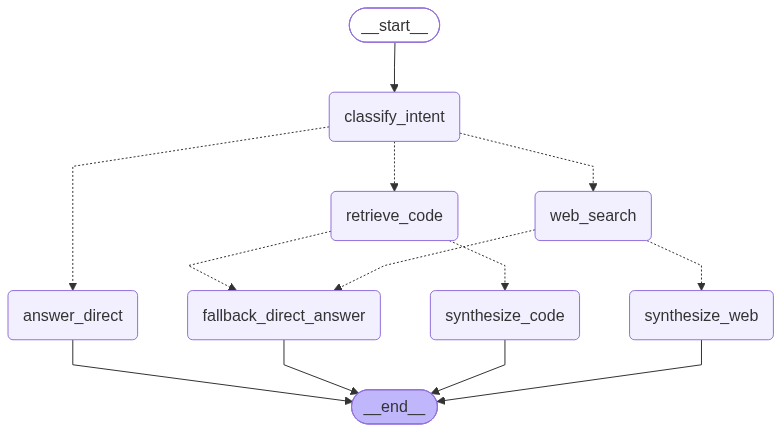

In [25]:
agent._build_graph()

### 12.2. Example 1: Conceptual / Programming Question (Direct Answer, No Web Search)

In [26]:
query_1 = "Explain the difference between a list and a tuple in Python."
print(f"User Question: {query_1}\n")

response_1 = agent.invoke(query_1)
print(f"Needs Web Search: {response_1['needs_web_search']}")
print(f"Search Results Count: {len(response_1['search_results'])}")
print("\n--- Agent Answer ---")
print(response_1['answer'])

User Question: Explain the difference between a list and a tuple in Python.

Needs Web Search: False
Search Results Count: 0

--- Agent Answer ---
In Python, **lists** and **tuples** are both sequence types, but they have key differences:

1. **Mutability**:
   - **List**: Mutable (can be modified after creation—elements can be added, removed, or changed).
   - **Tuple**: Immutable (cannot be modified after creation—no additions, deletions, or changes).

2. **Syntax**:
   - **List**: Uses square brackets `[]` (e.g., `[1, 2, 3]`).
   - **Tuple**: Uses parentheses `()` (e.g., `(1, 2, 3)`). The parentheses are optional for unambiguous cases (e.g., `1, 2, 3`).

3. **Performance**:
   - Tuples are generally **faster** than lists due to their immutability (fixed memory allocation).
   - Lists are **slower** but more flexible for dynamic operations.

4. **Use Cases**:
   - Use **lists** for collections that need modification (e.g., appending, sorting).
   - Use **tuples** for fixed data (e.g.

### 12.3. Example 2: Real-time / Dynamic Question (Web Search + Synthesis)

In [27]:
query_2 = "What is the latest stable version of LangGraph and its key new features?"
print(f"User Question: {query_2}\n")

response_2 = agent.invoke(query_2)
print(f"Needs Web Search: {response_2['needs_web_search']}")
print(f"Decided Route: {response_2['route']}")
print(f"Number of Search Results Used: {len(response_2['search_results'])}")
print("\n--- Agent Answer (with Citations) ---")
print(response_2['answer'])

User Question: What is the latest stable version of LangGraph and its key new features?

Needs Web Search: True
Decided Route: RouteDecision.WEB_SEARCH
Number of Search Results Used: 3

--- Agent Answer (with Citations) ---
The latest stable version of LangGraph is **1.2.11** [1].

Key new features introduced in recent versions include:
- **Middleware support**, allowing logic injection at any point in the agent loop (before/after LLM calls, around tool execution, or before/after the entire agent run) [2].
- **Standard content blocks**, enabling provider-agnostic LLM outputs [2].
- A **graph-based execution model** for reliable agentic systems, with full backward compatibility [3].

### Sources:
[1] https://github.com/langchain-ai/langgraph/releases
[2] https://medium.com/@romerorico.hugo/langgraph-1-0-released-no-breaking-changes-all-the-hard-won-lessons-8939d500ca7c
[3] https://www.langchain.com/blog/langchain-langgraph-1dot0


In [28]:
rag_query = ""
response = agent.invoke(rag_query)

print(f"Query: {rag_query}")
print(f"Decided Route: {response['route']}")
print(f"Retrieved Chunks Count: {len(response['retrieved_chunks'])}")
print("\n--- Answer ---")
print(response["answer"])


Query: 
Decided Route: RouteDecision.DIRECT
Retrieved Chunks Count: 0

--- Answer ---
Understood. Please provide the question or topic you'd like me to address.


In [29]:

# 1. Initialize the hardened agent
agent = QAAgent()

# 2. Test Normal Query
print("=== Test 1: Standard Query ===")
res1 = agent.invoke("What is the difference between an abstract class and an interface in Python?")
print("Fallback Used:", res1.get("fallback_used"))
print("Answer:\n", res1["answer"][:300], "...\n")

# 3. Test Fault Tolerance: Code query on an empty/non-existent topic
print("=== Test 2: RAG Fallback (No Chunks Found) ===")
res2 = agent.invoke("How does quantum_teleportation_flux_capacitor() function work in this repository?")
print("Fallback Used:", res2.get("fallback_used"))
print("Error Log:", res2.get("error_log"))
print("Answer:\n", res2["answer"][:300], "...\n")


=== Test 1: Standard Query ===
Fallback Used: False
Answer:
 In Python, the key differences between an **abstract class** and an **interface** are:

1. **Definition**:
   - **Abstract Class**: A class that cannot be instantiated and may contain both abstract methods (unimplemented) and concrete methods (implemented).
   - **Interface**: A class with only abst ...

=== Test 2: RAG Fallback (No Chunks Found) ===
Fallback Used: False
Error Log: []
Answer:
 After reviewing the provided code snippets, I can confirm that the `quantum_teleportation_flux_capacitor()` function is **not present** in any of the retrieved files. The snippets all originate from `fastapi_ml_model.ipynb` and contain JavaScript code related to Google Colab's interactive dataframes ...



### 12.4. Example 3: Inspecting Search Results & Sources

In [30]:
# print("Retrieved Search Sources for Query 2:")
# for res in response_2["search_results"]:
#     print(f"\n[{res['id']}] {res['title']}")
#     print(f"    URL: {res['url']}")
#     print(f"    Relevance Score: {res.get('score')}")
#     print(f"    Snippet Preview: {res['content'][:150]}...")